In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

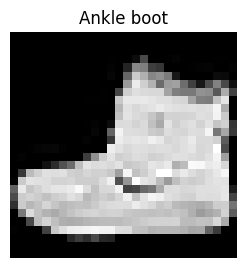

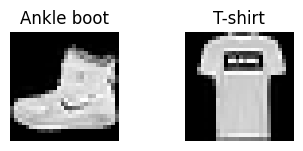

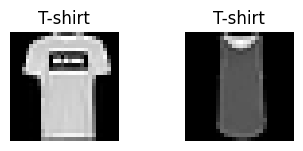

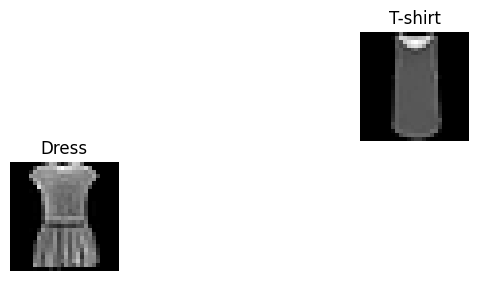

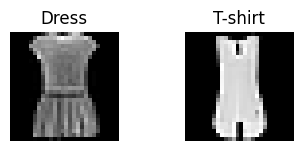

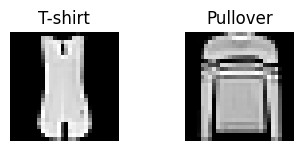

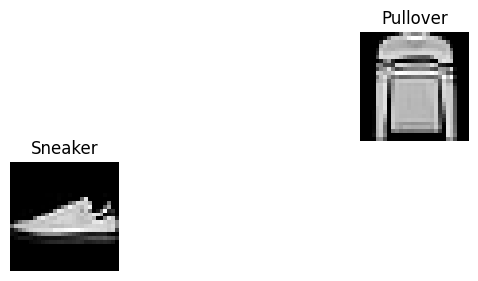

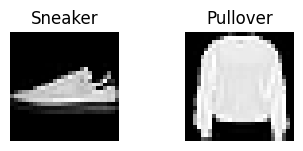

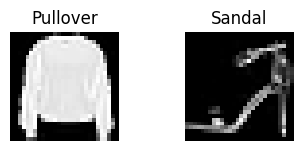

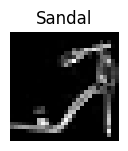

In [5]:
classes = [
"T-shirt",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"
]

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(classes[y_train[i]])

    plt.axis("off")

    plt.show()
    plt.subplot(3,3,i+1)
    
    plt.imshow(X_train[i], cmap="gray")
    
    plt.title(classes[y_train[i]])
    
    plt.axis("off")
plt.show() 

PARTE 1 — UNDERFITTING 

In [6]:
model_under = keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)),
  
  keras.layers.Dense(5, activation="relu"),
  
  keras.layers.Dense(10, activation="softmax")
])

d:\Documentos\Senac\deep learning\encontro12\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model_under.compile(
  optimizer="adam",
  
  loss="sparse_categorical_crossentropy",
  
  metrics=["accuracy"]
)


In [8]:
history_under = model_under.fit(
  X_train,
  y_train,
  
  epochs=5,
  
  validation_data=(X_test,y_test)
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4795 - loss: 1.3533 - val_accuracy: 0.6273 - val_loss: 1.0148
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7154 - loss: 0.7919 - val_accuracy: 0.7257 - val_loss: 0.6965
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7556 - loss: 0.6368 - val_accuracy: 0.7602 - val_loss: 0.6322
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7731 - loss: 0.5978 - val_accuracy: 0.7723 - val_loss: 0.6068
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7865 - loss: 0.5788 - val_accuracy: 0.7806 - val_loss: 0.5966


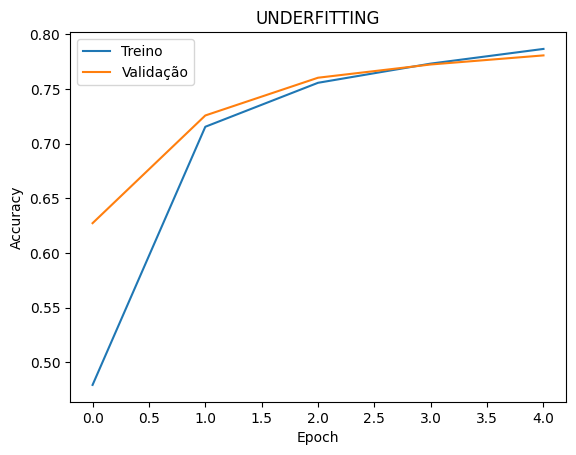

In [9]:
plt.plot(history_under.history['accuracy'], label='Treino')

plt.plot(history_under.history['val_accuracy'], label='Validação')

plt.title("UNDERFITTING")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

PARTE 2 — OVERFITTING

In [10]:
model_over = keras.Sequential([

  keras.layers.Flatten(input_shape=(28,28)),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dense(10, activation="softmax")
])

In [11]:
model_over.compile(
  optimizer="adam",
  
  loss="sparse_categorical_crossentropy",
  
  metrics=["accuracy"]
)

In [12]:
history_over = model_over.fit(
  X_train,
  y_train,
  
  epochs=20,
  
  validation_data=(X_test,y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8261 - loss: 0.4774 - val_accuracy: 0.8318 - val_loss: 0.4939
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8652 - loss: 0.3671 - val_accuracy: 0.8616 - val_loss: 0.3877
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8784 - loss: 0.3298 - val_accuracy: 0.8644 - val_loss: 0.3704
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8861 - loss: 0.3057 - val_accuracy: 0.8739 - val_loss: 0.3585
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8944 - loss: 0.2867 - val_accuracy: 0.8760 - val_loss: 0.3591
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8979 - loss: 0.2727 - val_accuracy: 0.8789 - val_loss: 0.3441
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9011 - loss: 0.2609 - val_accuracy: 0.8859 - val_loss: 0.3368
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9056 - loss: 0

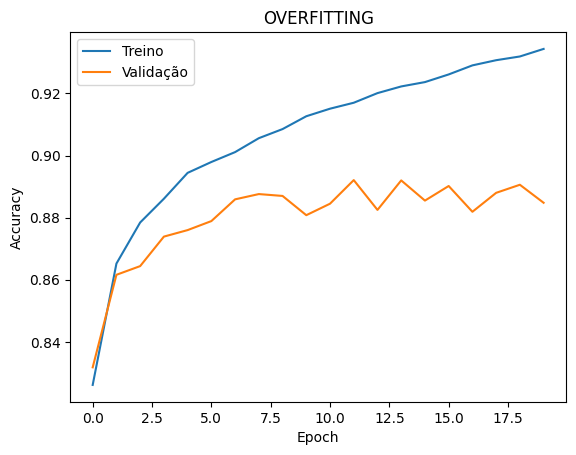

In [13]:
plt.plot(history_over.history['accuracy'], label='Treino')

plt.plot(history_over.history['val_accuracy'], label='Validação')

plt.title("OVERFITTING")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

PARTE 3 — REGULARIZAÇÃO 

In [14]:
model_reg = keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dropout(0.3),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dropout(0.3),
  
  keras.layers.Dense(10, activation="softmax")
]) 

In [18]:
# EarlyStopping 
early_stop = keras.callbacks.EarlyStopping(
  monitor='val_loss',
  
  patience=3
)

In [19]:
model_reg.compile(
  optimizer="adam",
  
  loss="sparse_categorical_crossentropy",
  
  metrics=["accuracy"]
)

In [21]:
history_reg = model_reg.fit(
  X_train,
  y_train,
  
  epochs=20,
  
  validation_data=(X_test,y_test),
  
  callbacks=[early_stop]
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8845 - loss: 0.3148 - val_accuracy: 0.8776 - val_loss: 0.3363
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8863 - loss: 0.3066 - val_accuracy: 0.8821 - val_loss: 0.3358
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8863 - loss: 0.3053 - val_accuracy: 0.8820 - val_loss: 0.3247
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8908 - loss: 0.2960 - val_accuracy: 0.8820 - val_loss: 0.3271
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8905 - loss: 0.2964 - val_accuracy: 0.8765 - val_loss: 0.3493
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8925 - loss: 0.2910 - val_accuracy: 0.8814 - val_loss: 0.3277


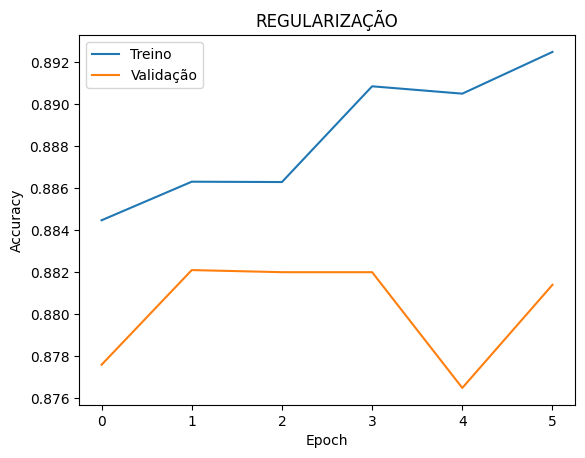

In [22]:
plt.plot(history_reg.history['accuracy'], label='Treino')

plt.plot(history_reg.history['val_accuracy'], label='Validação')

plt.title("REGULARIZAÇÃO")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
"""
RESPONDA:

1. Qual modelo apresentou underfitting?

O modelo model_under apresentou underfitting, pois era muito simples, com poucos neurônios, e teve dificuldade para aprender bem os padrões do dataset Fashion MNIST.

2. Qual modelo apresentou overfitting?

O modelo model_over apresentou overfitting, pois era mais complexo, com várias camadas densas de 512 neurônios. Ele tende a aprender muito bem os dados de treino, mas não melhora na mesma proporção nos dados de validação.

3. O Dropout ajudou? Como?

Sim. O Dropout ajudou porque desligou aleatoriamente parte dos neurônios durante o treinamento, dificultando que o modelo apenas memorizasse os dados de treino. Isso ajuda o modelo a generalizar melhor para dados novos.

4. O EarlyStopping interrompeu o treinamento em qual momento?

O EarlyStopping interrompeu o treinamento quando a perda de validação, val_loss, parou de melhorar por 3 épocas seguidas. No meu teste, ele interrompeu aproximadamente na época: Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8925 - loss: 0.2910 - val_accuracy: 0.8814 - val_loss: 0.3277.

5. Qual modelo apresentou melhor generalização?

O modelo com regularização, model_reg, apresentou melhor generalização, pois usou Dropout e EarlyStopping, reduzindo o overfitting e mantendo um desempenho mais equilibrado entre treino e validação.
"""